# 0h — Harmonize mouse `cell_states` on Object B (orth + macro)

* **Developed by:** Anna Maguza
* **Affilation:** CellZome, a GSK company
* **Created date:** 2026-05-17
* **Last modified date:** 2026-05-18

Object B (orth) carries `cell_states='unknown'` for all 25 485 mouse cells, because `0e_build_object_B_orth` never mapped study-specific `cell_type` values to harmonised cell_states. This degrades scANVI (it sees mouse Stem cells as 'unknown' and loses the supervisory signal).

Apply the **same HARMONIZE mapping** used in `2_saturn/2b_saturn_train.ipynb` to mouse rows in:
1. `object_b_cross_species_orth.h5ad` (the only one missing harmonisation — its mouse `cell_states` are 'unknown').
2. `object_b_macro_ep75.h5ad` / `object_b_macro_ep100.h5ad` — already inherit harmonised values from `saturn_input_{human,mouse}.h5ad`, but we double-check.

Mapping (per `cell_type` value, keyed by Study_name):

| Study | mapping (source `cell_type`) |
|---|---|
| GSE145866 | Lgr5+ ISC → Stem cells |
| Grün 2015 GSE62270 | organoid/primary Lgr5+ ISC → Stem cells |
| Grün 2016 | primary Lgr5+ ISC → Stem cells |
| Simmini 2014 GSE62784 | Lgr5+ ISC organoid → Stem cells |
| Yan 2017 GSE92865 | Lgr5+ ISC → Stem cells; Lgr5- non-ISC → Lgr5- non-ISC |
| Yan/Kuo 2017 GSE99457 | Lgr5+ ISC → Stem cells; Bmi1+ ISC → Stem cells; Lgr5- non-ISC → Lgr5- non-ISC; Prox1+ progenitor → Prox1+ progenitor |
| Haber 2017 | uses `Cell_Type` column; Stem → Stem cells; TA / Enterocyte / Enterocyte-Progenitor-{Early,Late} / Goblet / Paneth / Tuft-{1,2} → Tuft / Endocrine → Enteroendocrine |

Anything not in the mapping is set to 'unknown'.


In [1]:
import sys, datetime as dt, gc
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

REPO     = Path('/Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis')
DATA_OUT = Path('/Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced')
FIG_DIR  = REPO / 'analysis_enhanced' / 'figures' / '0_inputs'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(REPO / 'analysis_enhanced'))
from _lgr5_common import apply_style, WES_PALETTE
apply_style()

/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


## 2. HARMONIZE mapping (verbatim from 2b_saturn_train.ipynb)


In [2]:
# Maps Study_name -> (source_col, value_map). source_col is the per-study obs column
# holding the original cell-type label.
HARMONIZE = {
    'GSE145866 (10x)': {
        'source_col': 'cell_type',
        'mapping': {'Lgr5+ ISC': 'Stem cells'},
    },
    'Grün 2015 GSE62270 (CEL-Seq)': {
        'source_col': 'cell_type',
        'mapping': {'organoid Lgr5+ ISC': 'Stem cells', 'primary Lgr5+ ISC': 'Stem cells'},
    },
    'Grün 2016 (CEL-Seq)': {
        'source_col': 'cell_type',
        'mapping': {'primary Lgr5+ ISC': 'Stem cells'},
    },
    'Simmini 2014 GSE62784': {
        'source_col': 'cell_type',
        'mapping': {'Lgr5+ ISC organoid': 'Stem cells'},
    },
    'Yan 2017 GSE92865 (10x)': {
        'source_col': 'cell_type',
        'mapping': {'Lgr5+ ISC': 'Stem cells', 'Lgr5- non-ISC': 'Lgr5- non-ISC'},
    },
    'Yan/Kuo 2017 GSE99457 (10x)': {
        'source_col': 'cell_type',
        'mapping': {
            'Lgr5+ ISC':         'Stem cells',
            'Bmi1+ ISC':         'Stem cells',
            'Lgr5- non-ISC':     'Lgr5- non-ISC',
            'Prox1+ progenitor': 'Prox1+ progenitor',
        },
    },
    'Haber 2017 (Smart-Seq2)': {
        'source_col': 'Cell_Type',
        'mapping': {
            'Stem':                          'Stem cells',
            'TA':                            'TA',
            'Enterocyte':                    'Enterocyte',
            'Enterocyte-Progenitor-Early':   'Enterocyte-Progenitor-Early',
            'Enterocyte-Progenitor-Late':    'Enterocyte-Progenitor-Late',
            'Goblet':                        'Goblet',
            'Paneth':                        'Paneth',
            # FACS-derived Haber labels (all stem populations):
            'LGR5+ stem cell':              'Stem cells',
            'LGR5- stem cell':              'Stem cells',
            'LGR5- CD24- EpCAM+ stem cell': 'Stem cells',
            'Tuft-1': 'Tuft', 'Tuft-2': 'Tuft', 'Tuft': 'Tuft',
            'Endocrine':                     'Enteroendocrine',
        },
    },
}

def harmonize_mouse(adata):
    """In-place: rewrite cell_states for mouse cells using HARMONIZE per Study_name.
    Cells with no mapping → 'unknown'. Human cells are left untouched."""
    is_mouse = (adata.obs['species'].astype(str) == 'mouse').values
    new = adata.obs['cell_states'].astype(str).to_numpy().copy()
    sn = adata.obs['Study_name'].astype(str).to_numpy()
    n_changed = 0
    for study, cfg in HARMONIZE.items():
        src = cfg['source_col']
        mp = cfg['mapping']
        if src not in adata.obs.columns:
            print(f'  WARNING: {study}: missing source col {src!r} → all mouse cells stay unknown')
            continue
        src_arr = adata.obs[src].astype(str).to_numpy()
        m = is_mouse & (sn == study)
        for i in np.where(m)[0]:
            mapped = mp.get(src_arr[i], 'unknown')
            if mapped != new[i]:
                new[i] = mapped
                n_changed += 1
    adata.obs['cell_states'] = pd.Categorical(new)
    print(f'  changed cell_states for {n_changed} mouse cells')
    return adata

## 3. Apply to Object B (orth, macro_ep75, macro_ep100)

Also rebuild `lgr5_label` since some 'Unknown' rows now have a proper `cell_states`.


In [3]:
def rebuild_lgr5_label(adata):
    cs = adata.obs['cell_states'].astype(str)
    st = adata.obs['lgr5_status'].astype(str)
    label = cs.copy()
    label[st == 'LGR5+'] = 'LGR5+'
    label[st == 'LGR5-'] = 'LGR5-'
    unknown_mask = (cs.isin(['unknown', 'nan', 'NaN', 'None'])) & (st == 'LGR5_unknown')
    label[unknown_mask] = 'Unknown'
    adata.obs['lgr5_label'] = pd.Categorical(label)
    return adata

TARGETS = [
    'object_b_cross_species_orth.h5ad',
    'object_b_macro_ep75.h5ad',
    'object_b_macro_ep100.h5ad',
]
before_after = {}
for fname in TARGETS:
    p = DATA_OUT / fname
    if not p.exists():
        print(f'{fname}: missing — skip'); continue
    print(f'\n=== {fname} ===')
    a = sc.read_h5ad(p)
    is_mouse = (a.obs['species'].astype(str) == 'mouse').values
    before = a.obs.loc[is_mouse, 'cell_states'].astype(str).value_counts().to_dict()
    a = harmonize_mouse(a)
    a = rebuild_lgr5_label(a)
    after = a.obs.loc[is_mouse, 'cell_states'].astype(str).value_counts().to_dict()
    before_after[fname] = (before, after)
    hist = dict(a.uns.get('processing_history', {}))
    hist[f'mouse_cell_states_harmonised_{dt.datetime.now().strftime("%Y%m%d_%H%M%S")}'] = (
        'Applied HARMONIZE mapping (per 2b_saturn_train.ipynb) to mouse cell_states; '
        'rebuilt lgr5_label.'
    )
    a.uns['processing_history'] = hist
    a.write_h5ad(p)
    print(f'  before: {before}')
    print(f'  after:  {after}')
    print(f'  wrote {p}')
    del a; gc.collect()


=== object_b_cross_species_orth.h5ad ===


  changed cell_states for 25017 mouse cells


  before: {'unknown': 25485}
  after:  {'Stem cells': 19102, 'Lgr5- non-ISC': 3735, 'Prox1+ progenitor': 1336, 'unknown': 468, 'TA': 190, 'Enterocyte': 149, 'Goblet': 118, 'Enterocyte-Progenitor-Early': 112, 'Tuft': 99, 'Paneth': 69, 'Enterocyte-Progenitor-Late': 68, 'Enteroendocrine': 39}
  wrote /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/object_b_cross_species_orth.h5ad

=== object_b_macro_ep75.h5ad ===


  changed cell_states for 0 mouse cells


  before: {'Stem cells': 19102, 'Lgr5- non-ISC': 3735, 'Prox1+ progenitor': 1336, 'unknown': 468, 'TA': 190, 'Enterocyte': 149, 'Goblet': 118, 'Enterocyte-Progenitor-Early': 112, 'Tuft': 99, 'Paneth': 69, 'Enterocyte-Progenitor-Late': 68, 'Enteroendocrine': 39}
  after:  {'Stem cells': 19102, 'Lgr5- non-ISC': 3735, 'Prox1+ progenitor': 1336, 'unknown': 468, 'TA': 190, 'Enterocyte': 149, 'Goblet': 118, 'Enterocyte-Progenitor-Early': 112, 'Tuft': 99, 'Paneth': 69, 'Enterocyte-Progenitor-Late': 68, 'Enteroendocrine': 39}
  wrote /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/object_b_macro_ep75.h5ad

=== object_b_macro_ep100.h5ad ===


  changed cell_states for 0 mouse cells


  before: {'Stem cells': 19102, 'Lgr5- non-ISC': 3735, 'Prox1+ progenitor': 1336, 'unknown': 468, 'TA': 190, 'Enterocyte': 149, 'Goblet': 118, 'Enterocyte-Progenitor-Early': 112, 'Tuft': 99, 'Paneth': 69, 'Enterocyte-Progenitor-Late': 68, 'Enteroendocrine': 39}
  after:  {'Stem cells': 19102, 'Lgr5- non-ISC': 3735, 'Prox1+ progenitor': 1336, 'unknown': 468, 'TA': 190, 'Enterocyte': 149, 'Goblet': 118, 'Enterocyte-Progenitor-Early': 112, 'Tuft': 99, 'Paneth': 69, 'Enterocyte-Progenitor-Late': 68, 'Enteroendocrine': 39}
  wrote /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/object_b_macro_ep100.h5ad


## 4. Verification figure — cell_states per Study (mouse) after harmonisation


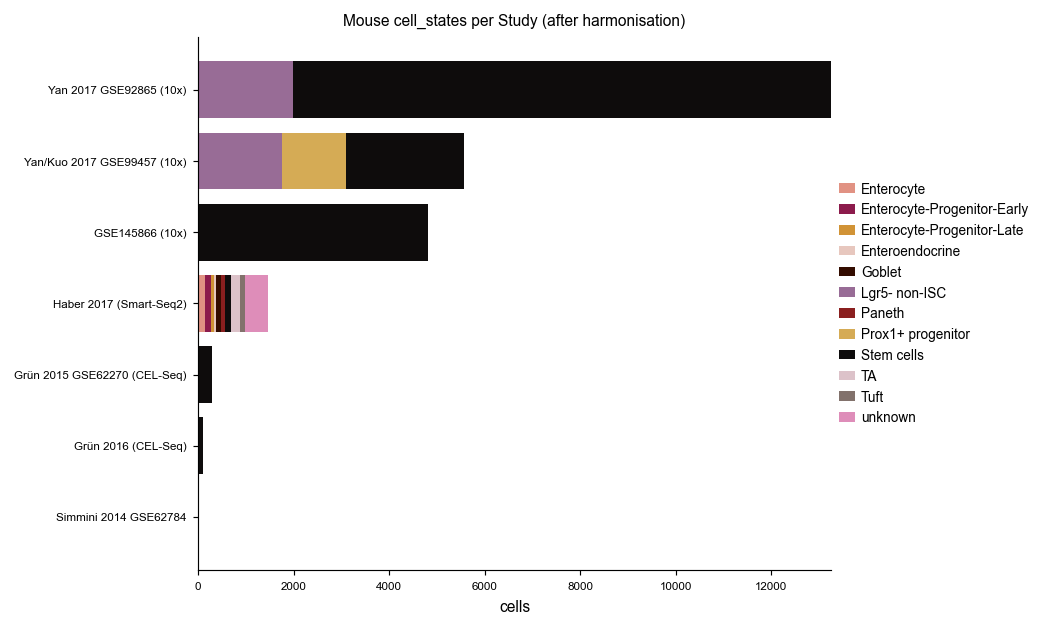

cell_states,Enterocyte,Enterocyte-Progenitor-Early,Enterocyte-Progenitor-Late,Enteroendocrine,Goblet,Lgr5- non-ISC,Paneth,Prox1+ progenitor,Stem cells,TA,Tuft,unknown
Study_name,,,,,,,,,,,,
Simmini 2014 GSE62784,0,0,0,0,0,0,0,0,16,0,0,0
Grün 2016 (CEL-Seq),0,0,0,0,0,0,0,0,96,0,0,0
Grün 2015 GSE62270 (CEL-Seq),0,0,0,0,0,0,0,0,288,0,0,0
Haber 2017 (Smart-Seq2),149,112,68,39,118,0,69,0,141,190,99,468
GSE145866 (10x),0,0,0,0,0,0,0,0,4815,0,0,0
Yan/Kuo 2017 GSE99457 (10x),0,0,0,0,0,1756,0,1336,2478,0,0,0
Yan 2017 GSE92865 (10x),0,0,0,0,0,1979,0,0,11268,0,0,0


In [4]:
a = sc.read_h5ad(DATA_OUT / 'object_b_cross_species_orth.h5ad', backed='r')
df = a.obs[['species','Study_name','cell_states']].copy()
a.file.close()

# Mouse-only cross-tab
m_df = df[df['species'].astype(str) == 'mouse']
ct = (m_df.groupby(['Study_name', 'cell_states'], observed=True).size()
            .unstack(fill_value=0))
ct = ct.reindex(ct.sum(axis=1).sort_values().index)
states = list(ct.columns)
palette = [WES_PALETTE[i % len(WES_PALETTE)] for i in range(len(states))]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
left = np.zeros(len(ct))
for i, s in enumerate(states):
    ax.barh(ct.index, ct[s], left=left, color=palette[i], label=s, edgecolor='none')
    left += ct[s].values
ax.set_xlabel('cells', fontsize=8)
ax.set_title('Mouse cell_states per Study (after harmonisation)', fontsize=8)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=7)
fig.tight_layout()
fig.savefig(FIG_DIR / 'object_b_mouse_cell_states_after_harmonisation.pdf')
fig.savefig(FIG_DIR / 'object_b_mouse_cell_states_after_harmonisation.png', dpi=300)
ct.to_csv(FIG_DIR / 'object_b_mouse_cell_states_after_harmonisation.csv')
plt.show()
display(ct)

## 5. Outputs

Updated h5ad files (overwritten in place; `uns.processing_history` records the change):
- `object_b_cross_species_orth.h5ad`
- `object_b_macro_ep75.h5ad`
- `object_b_macro_ep100.h5ad`

Figure / CSV:
- `analysis_enhanced/figures/0_inputs/object_b_mouse_cell_states_after_harmonisation.{pdf,png,csv}`
